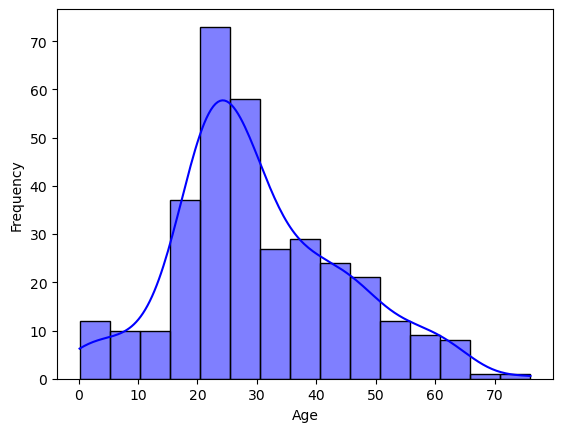

     PassengerId  Survived  Pclass  \
0            892         0       3   
1            893         1       3   
2            894         0       2   
3            895         0       3   
4            896         1       3   
..           ...       ...     ...   
413         1305         0       3   
414         1306         1       1   
415         1307         0       3   
416         1308         0       3   
417         1309         0       3   

                                             Name  Sex   Age  SibSp  Parch  \
0                                Kelly, Mr. James    1  34.5      0      0   
1                Wilkes, Mrs. James (Ellen Needs)    0  47.0      1      0   
2                       Myles, Mr. Thomas Francis    1  62.0      0      0   
3                                Wirz, Mr. Albert    1  27.0      0      0   
4    Hirvonen, Mrs. Alexander (Helga E Lindqvist)    0  22.0      1      1   
..                                            ...  ...   ...    ...    ... 

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
df=pd.read_csv('TitanicDataset.csv')
df.head(10)
df.isnull().sum()
#Finding missing data %age
#null_percentage=(df.isnull().sum()/len(df))*100
#Handling null values
sns.histplot(df['Age'],kde=True,color='blue')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()
#As tail is right skewed,fill missing values with median
df['Age']=df['Age'].fillna(df['Age'].median())
df.isnull().sum()
#Filled,,now do same thing with Fare
df['Fare']=df['Fare'].fillna(df['Fare'].median())
df.isnull().sum()
df=df.drop('Cabin',axis=1) #No need here
df.columns

#Label Encoding of column sex
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
print(df)

col=df[['Age','Sex','Pclass','Fare']]
X=col
y=df['Survived']
print(X,y)

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train,X_test)
print(y_train,y_test)
print('Spliting Done')
knn=KNeighborsClassifier(n_neighbors=4)
knn.fit(X_train,y_train)
print('training done')
y_pred=knn.predict(X_test)
print(y_pred)

accuracy=accuracy_score(y_test,y_pred)
print('Accuracy:',accuracy)


#----------------NORMALIZATION/SCALING----------------